# Classification Models

## Gym Members Exercise Dataset

**Author:** Sarah Suliman  
**Course:** CSPB 4502: Data Mining  
**Project:** Discovering Fitness Profiles and Workout Performance Patterns Through Data Mining

## 1. Objective

The goal of this notebook is to predict a gym member's experience level using demographic, physiological, and workout-related characteristics.

Three models will be compared:

- Majority-class baseline
- Decision Tree
- Random Forest

The models will be evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

In [33]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [34]:
DATA_PATH = Path("../data/processed/gym_members_exercise_cleaned.csv")
FIGURES_DIR = Path("../figures")
MODELS_DIR = Path("../models")

df = pd.read_csv(DATA_PATH)

df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Heart_Rate_Reserve,Calories_Per_Hour,Water_Intake_Per_Hour,BMI_Category
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20,120,776.923077,2.071006,Obese
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00,113,679.230769,1.615385,Obese
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71,113,609.909910,2.072072,Normal
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41,134,901.694915,3.559322,Underweight
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39,120,868.750000,4.375000,Underweight


## 2. Define the Target and Features

In [35]:
TARGET = "Experience_Level"

numeric_features = [
    "Age",
    "Weight (kg)",
    "Height (m)",
    "BMI",
    "Max_BPM",
    "Avg_BPM",
    "Resting_BPM",
    "Heart_Rate_Reserve",
    "Session_Duration (hours)",
    "Calories_Burned",
    "Fat_Percentage",
    "Water_Intake (liters)",
    "Workout_Frequency (days/week)",
]

categorical_features = [
    "Gender",
    "Workout_Type",
]

features = numeric_features + categorical_features

X = df[features].copy()
y = df[TARGET].copy()

The target variable is `Experience_Level`, which contains three classes. The predictor variables include demographic characteristics, heart-rate measurements, workout behavior, body composition, and exercise outcomes.

In [36]:
y.value_counts().sort_index()

Experience_Level
1    376
2    406
3    191
Name: count, dtype: int64

The experience-level classes are not perfectly balanced, so the train/test split will use stratification to preserve class proportions.

## 3. Train/Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 778
Testing rows: 195


The dataset is divided into 80% training data and 20% testing data. Stratification helps maintain the distribution of experience levels in both subsets.

## 4. Build the Preprocessing Pipeline

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

Numerical features are standardized so that differences in measurement scales do not influence the models. Categorical variables are converted into numerical indicator variables using one-hot encoding.

## 5. Baseline Model

In [39]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline Accuracy: {baseline_accuracy:.3f}")

Baseline Accuracy: 0.421


The baseline model always predicts the most common experience level. It provides a minimum performance benchmark that the machine learning models should outperform.

## 6. Decision Tree Classifier

In [40]:
decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=8,
                random_state=42
            )
        )
    ]
)

decision_tree.fit(
    X_train,
    y_train
)

tree_predictions = decision_tree.predict(X_test)

In [41]:
tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

tree_precision = precision_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accuracy: {tree_accuracy:.3f}")
print(f"Precision: {tree_precision:.3f}")
print(f"Recall: {tree_recall:.3f}")
print(f"F1-score: {tree_f1:.3f}")

Accuracy: 0.908
Precision: 0.912
Recall: 0.908
F1-score: 0.907


The Decision Tree provides an interpretable classification model that learns rule-based splits from the training data. Its performance will be compared with both the baseline and Random Forest models.

## 7. Random Forest Classifier

In [42]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=4,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest.fit(
    X_train,
    y_train
)

forest_predictions = random_forest.predict(X_test)

In [43]:
forest_accuracy = accuracy_score(
    y_test,
    forest_predictions
)

forest_precision = precision_score(
    y_test,
    forest_predictions,
    average="weighted",
    zero_division=0
)

forest_recall = recall_score(
    y_test,
    forest_predictions,
    average="weighted",
    zero_division=0
)

forest_f1 = f1_score(
    y_test,
    forest_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accuracy: {forest_accuracy:.3f}")
print(f"Precision: {forest_precision:.3f}")
print(f"Recall: {forest_recall:.3f}")
print(f"F1-score: {forest_f1:.3f}")

Accuracy: 0.897
Precision: 0.898
Recall: 0.897
F1-score: 0.897


Random Forest combines many decision trees and typically provides more stable predictions than a single tree. Class weighting is used to reduce the effect of class imbalance.

## 8. Model Comparison

In [44]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Baseline",
            "Decision Tree",
            "Random Forest"
        ],
        "Accuracy": [
            baseline_accuracy,
            tree_accuracy,
            forest_accuracy
        ],
        "F1_Score": [
            f1_score(
                y_test,
                baseline_predictions,
                average="weighted",
                zero_division=0
            ),
            tree_f1,
            forest_f1
        ]
    }
)

comparison

,Model,Accuracy,F1_Score
0,Baseline,0.420513,0.248968
1,Decision Tree,0.907692,0.907048
2,Random Forest,0.897436,0.897252


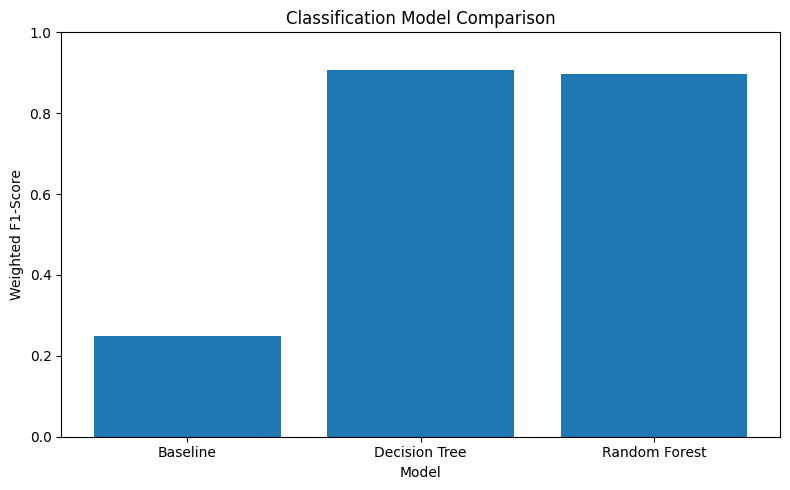

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["F1_Score"]
)

plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Weighted F1-Score")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "classification_model_comparison.png",
    dpi=300
)

plt.show()

The model comparison shows whether the trained classifiers outperform the majority-class baseline. Weighted F1-score is useful because it accounts for both precision and recall while considering the size of each class.

## 9. Confusion Matrix

In [46]:
best_predictions = tree_predictions
best_model_name = "Decision Tree"

cm = confusion_matrix(
    y_test,
    best_predictions
)

cm

array([[61, 14,  0],
       [ 4, 78,  0],
       [ 0,  0, 38]])

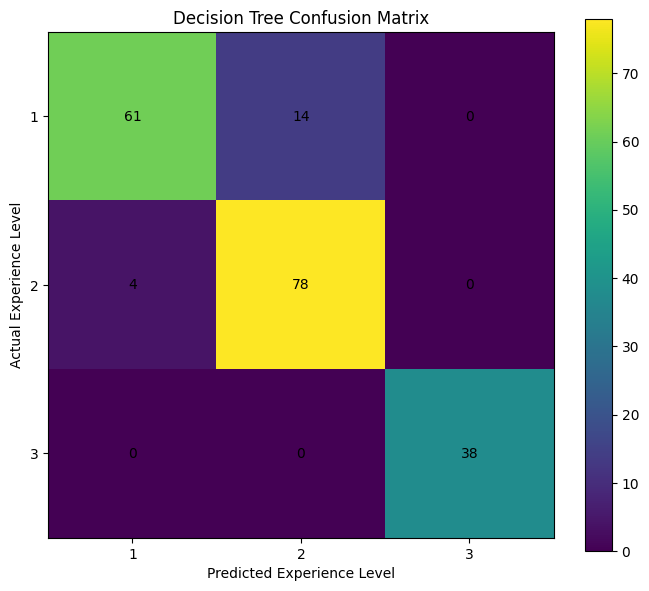

In [47]:
plt.figure(figsize=(7, 6))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    f"{best_model_name} Confusion Matrix"
)

plt.xlabel("Predicted Experience Level")
plt.ylabel("Actual Experience Level")

plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xticks(
    range(3),
    [1, 2, 3]
)

plt.yticks(
    range(3),
    [1, 2, 3]
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "classification_confusion_matrix.png",
    dpi=300
)

plt.show()

The confusion matrix shows how often each experience level is correctly or incorrectly classified. Values along the diagonal represent correct predictions, while off-diagonal values represent misclassifications.

## 10. Classification Report

In [48]:
print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1       0.94      0.81      0.87        75
           2       0.85      0.95      0.90        82
           3       1.00      1.00      1.00        38

    accuracy                           0.91       195
   macro avg       0.93      0.92      0.92       195
weighted avg       0.91      0.91      0.91       195



The classification report provides class-level precision, recall, and F1-scores. These metrics help identify whether the model performs consistently across all three experience levels rather than relying only on overall accuracy.

## 11. Save Models

In [49]:
joblib.dump(
    baseline,
    MODELS_DIR / "baseline_classifier.joblib"
)

joblib.dump(
    decision_tree,
    MODELS_DIR / "decision_tree_classifier.joblib"
)

joblib.dump(
    random_forest,
    MODELS_DIR / "random_forest_classifier.joblib"
)

print("Classification models saved successfully.")

Classification models saved successfully.


## 12. Key Findings

The classification analysis compared a majority-class baseline with Decision Tree and Random Forest models for predicting gym member experience level. The trained classifiers were evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The strongest model provides evidence that workout behavior, physiological measurements, and body composition contain useful information for distinguishing different experience levels. However, model performance should be interpreted carefully because the dataset may contain relationships that were influenced by how the experience-level variable was originally defined.